# ML Experiment 4: Classification - Logistic Regression, Decision Tree, KNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

# Generate dataset
X, y = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Training: {X_train.shape[0]}, Testing: {X_test.shape[0]}")


Training: 210, Testing: 90


In [2]:
def plot_decision_boundary(model, X, y, title, ax, use_scaled=True):
    cmap_bg = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_pts = ListedColormap(['#FF0000', '#0000FF'])
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pts, edgecolors='black', s=20)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')


## A. Logistic Regression

In [3]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_sc, y_train)
y_pred_lr = lr_model.predict(X_test_sc)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Results:
Accuracy: 0.9556

Confusion Matrix:
[[44  2]
 [ 2 42]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        46
           1       0.95      0.95      0.95        44

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



## B. Decision Tree

In [4]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


Decision Tree Results:
Accuracy: 0.9111

Confusion Matrix:
[[44  2]
 [ 6 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        46
           1       0.95      0.86      0.90        44

    accuracy                           0.91        90
   macro avg       0.92      0.91      0.91        90
weighted avg       0.91      0.91      0.91        90



## C. K-Nearest Neighbors

In [5]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_sc, y_train)
y_pred_knn = knn_model.predict(X_test_sc)

print("KNN Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


KNN Results:
Accuracy: 0.9556

Confusion Matrix:
[[45  1]
 [ 3 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.98      0.93      0.95        44

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



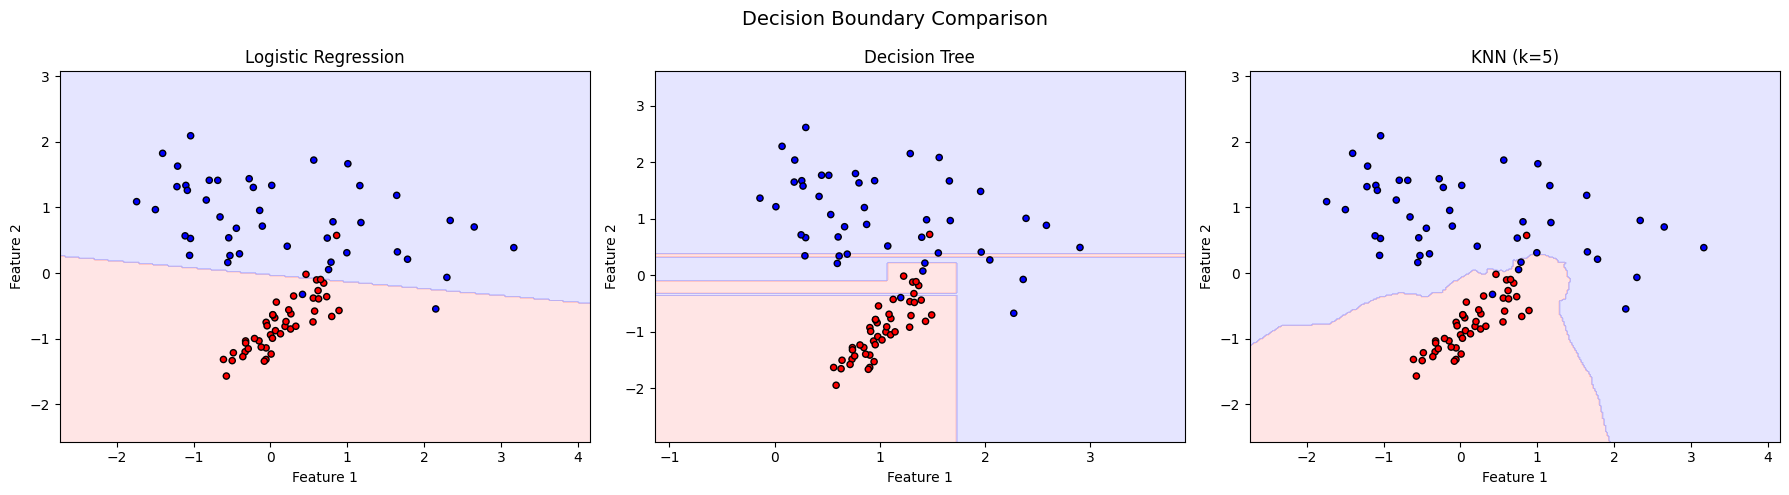


Model                       Accuracy
Logistic Regression           0.9556
Decision Tree                 0.9111
KNN (k=5)                     0.9556


In [6]:
# Decision Boundaries Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(lr_model, X_test_sc, y_test, 'Logistic Regression', axes[0])
plot_decision_boundary(dt_model, X_test, y_test, 'Decision Tree', axes[1])
plot_decision_boundary(knn_model, X_test_sc, y_test, 'KNN (k=5)', axes[2])

plt.suptitle('Decision Boundary Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*50)
print(f"{'Model':<25} {'Accuracy':>10}")
print("="*50)
print(f"{'Logistic Regression':<25} {accuracy_score(y_test, y_pred_lr):>10.4f}")
print(f"{'Decision Tree':<25} {accuracy_score(y_test, y_pred_dt):>10.4f}")
print(f"{'KNN (k=5)':<25} {accuracy_score(y_test, y_pred_knn):>10.4f}")


## Conclusion
We implemented and compared three classification algorithms: Logistic Regression (linear boundary), Decision Tree (step-wise/rectangular boundary), and KNN (flexible boundary). LR is fast and works well for linearly separable data. Decision Trees handle non-linear relationships without scaling. KNN is instance-based with flexible boundaries but requires scaling and has higher prediction time.

## Post-Experiment Answers
1. LR produces linear boundaries, DT produces rule-based rectangular boundaries, KNN produces irregular flexible boundaries.
2. Small k = complex boundary (overfitting), large k = smooth boundary (underfitting). Optimal k balances bias-variance.
3. The best model depends on data; DT often does well on non-linear data, LR on linear, KNN with proper k for moderate complexity.